# Q4

Train on MNIST dataset using an MLP. The original training dataset contains 60,000 images and test contains 10,000 images. If you are short on compute, use a stratified subset of a smaller number of images. But, the test set remains the same 10,000 images. Compare against RF and Logistic Regression models.  The metrics can be: F1-score, confusion matrix. What do you observe? What all digits are commonly confused?


In [ ]:
# Import necessary libraries
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# Load the MNIST dataset
mnist = fetch_openml('mnist_784')
X, y = mnist['data'], mnist['target']


/usr/local/lib/python3.10/dist-packages/sklearn/datasets/_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [ ]:
# Shape of the dataset
X.shape, y.shape

((70000, 784), (70000,))

In [ ]:
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, random_state=42)

## Random Forest

In [ ]:
accuracy_dict = {}
f1_dict = {}

for i in range(1, 50):
    rf = RandomForestClassifier(n_estimators=i, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    accuracy_dict[i] = rf.score(X_test, y_test)
    f1_dict[i] = f1_score(y_test, y_pred, average='weighted')
    print("For number of trees = ", i, "Accuracy = ", accuracy_dict[i], "F1 Score = ", f1_dict[i])


For number of trees =  1 Accuracy =  0.821 F1 Score =  0.8203983127507117
For number of trees =  2 Accuracy =  0.8201 F1 Score =  0.8171647661230143
For number of trees =  3 Accuracy =  0.8792 F1 Score =  0.8786275684486448
For number of trees =  4 Accuracy =  0.9094 F1 Score =  0.9089544402697777
For number of trees =  5 Accuracy =  0.9224 F1 Score =  0.9220641233975068
For number of trees =  6 Accuracy =  0.9304 F1 Score =  0.9301799488470001
For number of trees =  7 Accuracy =  0.9367 F1 Score =  0.9364940112376533
For number of trees =  8 Accuracy =  0.9403 F1 Score =  0.9401643545446424
For number of trees =  9 Accuracy =  0.9447 F1 Score =  0.944603280582206
For number of trees =  10 Accuracy =  0.9465 F1 Score =  0.9464245410962536
For number of trees =  11 Accuracy =  0.9485 F1 Score =  0.9483942014001617
For number of trees =  12 Accuracy =  0.9491 F1 Score =  0.9489906842788896
For number of trees =  13 Accuracy =  0.9501 F1 Score =  0.9499797451803937
For number of trees =  

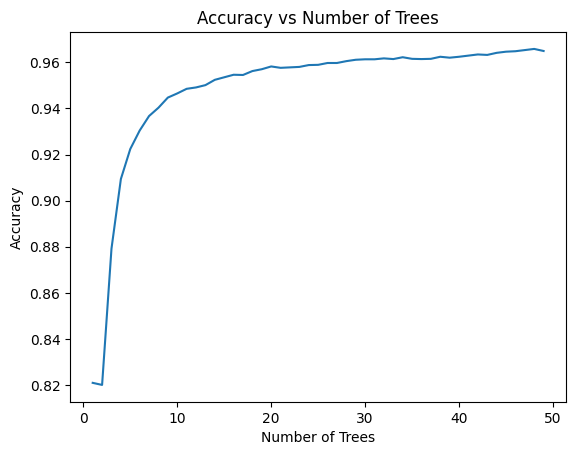

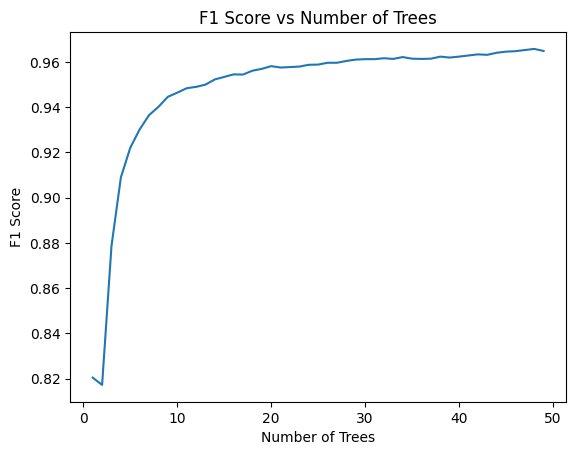

In [ ]:
# Plot the accuracy and f1 score
plt.figure()
plt.plot(list(accuracy_dict.keys()), list(accuracy_dict.values()))
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of Trees')
plt.show()


plt.figure()
plt.plot(list(f1_dict.keys()), list(f1_dict.values()))
plt.xlabel('Number of Trees')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Number of Trees')
plt.show()


In [ ]:
# Train RF and Logistic Regression models for comparison
rf = RandomForestClassifier(n_estimators=48, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=48, random_state=42)

## Logistic Regression

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


For solver =  lbfgs Accuracy =  0.8808 F1 Score =  0.8803011594039087


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


For solver =  liblinear Accuracy =  0.9135 F1 Score =  0.9131880507310179


/usr/local/lib/python3.10/dist-packages/sklearn/utils/optimize.py:210: ConvergenceWarning: newton-cg failed to converge. Increase the number of iterations.
  warnings.warn(


...

For solver =  newton-cholesky Accuracy =  0.914 F1 Score =  0.9136634562817737


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


For solver =  sag Accuracy =  0.9202 F1 Score =  0.920028979947647


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


For solver =  saga Accuracy =  0.9194 F1 Score =  0.9192169969829934


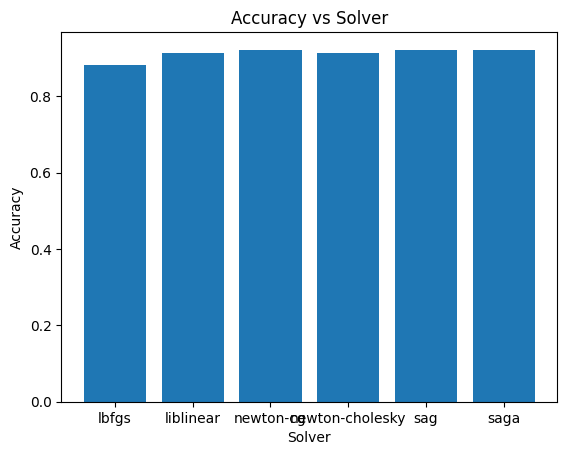

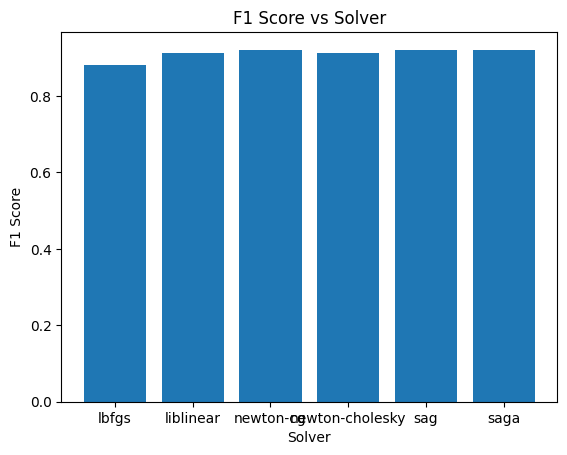

In [ ]:
accuracy_dict = {}
f1_dict = {}
for solver in ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']:
    lr = LogisticRegression(solver=solver, max_iter=10)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    accuracy_dict[solver] = lr.score(X_test, y_test)
    f1_dict[solver] = f1_score(y_test, y_pred, average='weighted')
    print("For solver = ", solver, "Accuracy = ", accuracy_dict[solver], "F1 Score = ", f1_dict[solver])


# Plot the accuracy and f1 score
plt.figure()
plt.bar(list(accuracy_dict.keys()), list(accuracy_dict.values()))
plt.xlabel('Solver')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Solver')
plt.show()

plt.figure()
plt.bar(list(f1_dict.keys()), list(f1_dict.values()))
plt.xlabel('Solver')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Solver')
plt.show()


In [ ]:
lr = LogisticRegression(solver='newton-cg', max_iter = 10)
lr.fit(X_train, y_train)


/usr/local/lib/python3.10/dist-packages/sklearn/utils/optimize.py:210: ConvergenceWarning: newton-cg failed to converge. Increase the number of iterations.
  warnings.warn(


LogisticRegression(max_iter=10, solver='newton-cg')

# MLP Classifier

In [13]:
# Train an MLP with 30, 20, and 10 neurons in the layers
mlp = MLPClassifier(hidden_layer_sizes=(30, 20), max_iter=50)
mlp.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(30, 20), max_iter=50)

MLP F1 Score: 0.9385388374122993
RF F1 Score: 0.9657792727435656
LR F1 Score: 0.9212384460916819


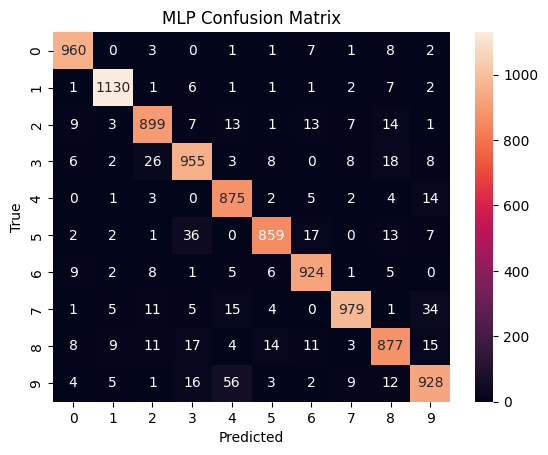

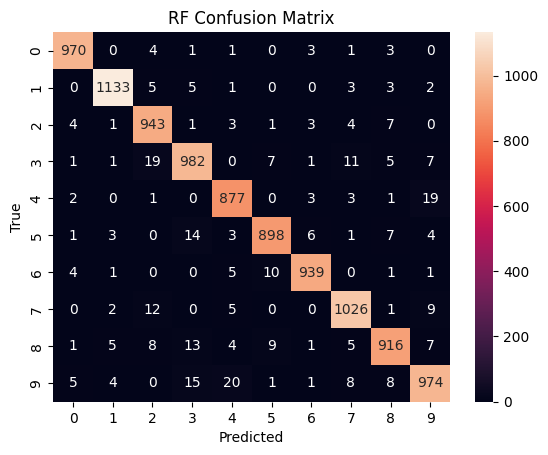

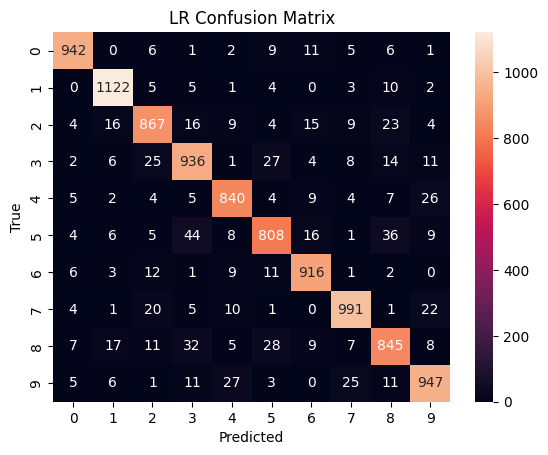

In [14]:
# Evaluate models using F1-score and confusion matrix
mlp_pred = mlp.predict(X_test)
rf_pred = rf.predict(X_test)
lr_pred = lr.predict(X_test)

mlp_f1 = f1_score(y_test, mlp_pred, average='weighted')
rf_f1 = f1_score(y_test, rf_pred, average='weighted')
lr_f1 = f1_score(y_test, lr_pred, average='weighted')

mlp_cm = confusion_matrix(y_test, mlp_pred)
rf_cm = confusion_matrix(y_test, rf_pred)
lr_cm = confusion_matrix(y_test, lr_pred)

import seaborn as sns
plt.figure()
sns.heatmap(mlp_cm, annot=True, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('MLP Confusion Matrix')

plt.figure()
sns.heatmap(rf_cm, annot=True, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('RF Confusion Matrix')

plt.figure()
sns.heatmap(lr_cm, annot=True, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('LR Confusion Matrix')

print('MLP F1 Score:', mlp_f1)
print('RF F1 Score:', rf_f1)
print('LR F1 Score:', lr_f1)



In [15]:
mlp_report = classification_report(y_test, mlp_pred)
rf_report = classification_report(y_test, rf_pred)
lr_report = classification_report(y_test, lr_pred)

print('MLP Classification Report:', mlp_report)
print('RF Classification Report:', rf_report)
print('LR Classification Report:', lr_report)

MLP Classification Report:               precision    recall  f1-score   support

           0       0.96      0.98      0.97       983
           1       0.97      0.98      0.98      1152
           2       0.93      0.93      0.93       967
           3       0.92      0.92      0.92      1034
           4       0.90      0.97      0.93       906
           5       0.96      0.92      0.94       937
           6       0.94      0.96      0.95       961
           7       0.97      0.93      0.95      1055
           8       0.91      0.91      0.91       969
           9       0.92      0.90      0.91      1036

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000

RF Classification Report:               precision    recall  f1-score   support

           0       0.98      0.99      0.98       983
           1       0.99      0.98      0.98      1152
           2       0.95  

Let us assume your MLP has 30 neurons in first layer, 20 in second layer and then 10 finally for the output layer (corresponding to 10 classes). On the trained MLP, plot the t-SNE for the output from the layer containing 20 neurons for the 10 digits. Contrast this with the t-SNE for the same layer but for an untrained model. What do you conclude?

In [17]:
mlp.coefs_[0].shape, mlp.coefs_[1].shape, mlp.coefs_[2].shape, len(mlp.coefs_)

((784, 30), (30, 20), (20, 10), 3)

In [18]:
mlp.intercepts_[0].shape, mlp.intercepts_[1].shape, mlp.intercepts_[2].shape, len(mlp.intercepts_)

((30,), (20,), (10,), 3)

In [19]:
X_test.shape

(10000, 784)

In [20]:
X_test_layer1 = mlp.coefs_[0].T @ X_test.T + mlp.intercepts_[0][:, None]
X_test_layer1.shape

(30, 10000)

In [21]:
X_test_layer1 = 1 / (1 + np.exp(-X_test_layer1))

/usr/local/lib/python3.10/dist-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


In [22]:
X_test_layer2 = mlp.coefs_[1].T @ X_test_layer1 + mlp.intercepts_[1][:, None]
X_test_layer2.shape


(20, 10000)

In [23]:
X_test_layer2 = 1 / (1 + np.exp(-X_test_layer2))
X_test_layer2.shape

(20, 10000)

(10000, 2)


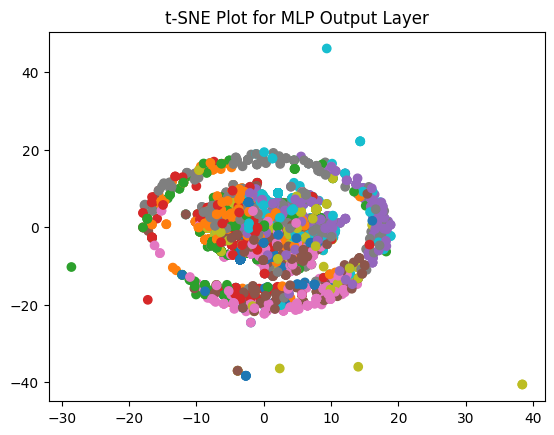

In [24]:
# Plot t-SNE for the output from the layer containing 20 neurons
tsne = TSNE(perplexity=1, n_components=2, n_iter=250, random_state=42)
X_embedded = tsne.fit_transform(X_test_layer2.T)
print(X_embedded.shape)
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_test.astype(int), cmap='tab10')
plt.title('t-SNE Plot for MLP Output Layer')
plt.show()


In [25]:
# Plot t-SNE for the output from the layer containing 20 neurons for the untrained model
mlp_untrained = MLPClassifier(hidden_layer_sizes=(30, 20), random_state=42, max_iter=0)
mlp_untrained.coefs_[0].shape, mlp_untrained.coefs_[1].shape, mlp_untrained.coefs_[2].shape, len(mlp_untrained.coefs_)



AttributeError: 'MLPClassifier' object has no attribute 'coefs_'

In [26]:
np.random.seed(42)
mlp_ut_coeff0 = np.random.rand(784, 30)
mlp_ut_coeff1 = np.random.rand(30, 20)
mlp_ut_coeff2 = np.random.rand(20, 10)
mlp_ut_intercept0 = np.random.rand(30,)
mlp_ut_intercept1 = np.random.rand(20,)
mlp_ut_intercept2 = np.random.rand(10,)

mlp_untrained.coefs_ = [mlp_ut_coeff0, mlp_ut_coeff1, mlp_ut_coeff2]
mlp_untrained.intercepts_ = [mlp_ut_intercept0, mlp_ut_intercept1, mlp_ut_intercept2]


In [27]:
X_test_layer1_untrained = mlp_ut_coeff0.T @ X_test.T + mlp_ut_intercept0[:, None]
X_test_layer1_untrained = 1 / (1 + np.exp(-X_test_layer1_untrained))

X_test_layer2_untrained = mlp_ut_coeff1.T @ X_test_layer1_untrained + mlp_ut_intercept1[:, None]
X_test_layer2_untrained = 1 / (1 + np.exp(-X_test_layer2_untrained))

X_test_layer2_untrained.shape

(20, 10000)

(10000, 2)


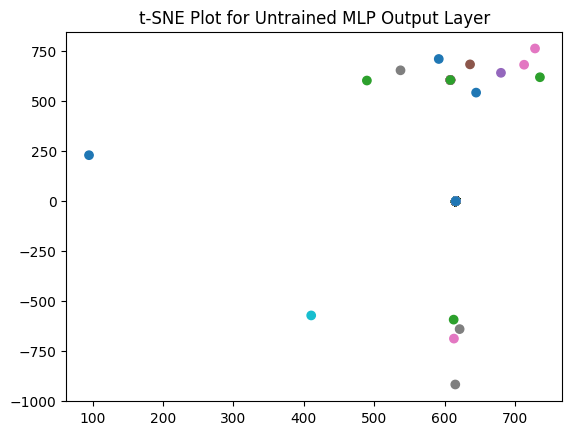

In [31]:
tsne = TSNE(perplexity=1, n_components=2, n_iter=250, random_state=4)
X_embedded_untrained = tsne.fit_transform(X_test_layer2_untrained.T)
print(X_embedded_untrained.shape)
plt.scatter(X_embedded_untrained[:, 0], X_embedded_untrained[:, 1], c=y_test.astype(int), cmap='tab10')
plt.title('t-SNE Plot for Untrained MLP Output Layer')
plt.show()


Now, use the trained MLP to predict on the Fashion-MNIST dataset. What do you observe? How do the embeddings (t-SNE viz for the second layer compare for MNIST and Fashion-MNIST images)

In [29]:
from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Load Fashion-MNIST dataset
fashion_mnist = fetch_openml(name='Fashion-MNIST')

X = fashion_mnist.data
y = fashion_mnist.target


/usr/local/lib/python3.10/dist-packages/sklearn/datasets/_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


/usr/local/lib/python3.10/dist-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


(20, 10000)
(10000, 2)


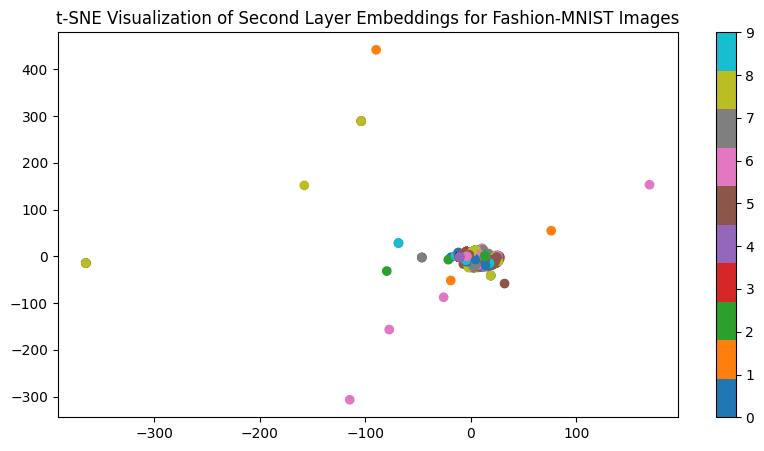

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, random_state=42)

X_test_layer1 = mlp.coefs_[0].T @ X_test.T + mlp.intercepts_[0][:, None]
X_test_layer1 = 1 / (1 + np.exp(-X_test_layer1))
X_test_layer2 = mlp.coefs_[1].T @ X_test_layer1 + mlp.intercepts_[1][:, None]
X_test_layer2 = 1 / (1 + np.exp(-X_test_layer2))
print(X_test_layer2.shape)

tsne = TSNE(perplexity=1, n_components=2, n_iter=250, random_state=42)
X_embedded = tsne.fit_transform(X_test_layer2.T)
print(X_embedded.shape)


plt.figure(figsize=(10, 5))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_test.astype(int), cmap='tab10')
plt.title('t-SNE Visualization of Second Layer Embeddings for Fashion-MNIST Images')
plt.colorbar()
plt.show()
